<a href="https://colab.research.google.com/github/MuhammadMuzammil67/Simple-Linear_Regression_Practice/blob/main/5ValuesLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
time = [5,7,12,16,20]
mass = [40,120,180,210,240]



In [ ]:
data = pd.DataFrame({'Time': time, 'Mass': mass})
print("Raw Data:\n", data.head())

Raw Data:
    Time  Mass
0     5    40
1     7   120
2    12   180
3    16   210
4    20   240


In [ ]:
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Time    5 non-null      int64
 1   Mass    5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


,Time,Mass
count,5.000000,5.000000
mean,12.000000,158.000000
std,6.204837,79.498428
min,5.000000,40.000000
25%,7.000000,120.000000
50%,12.000000,180.000000
75%,16.000000,210.000000
max,20.000000,240.000000


In [ ]:
clean_data = data.copy()

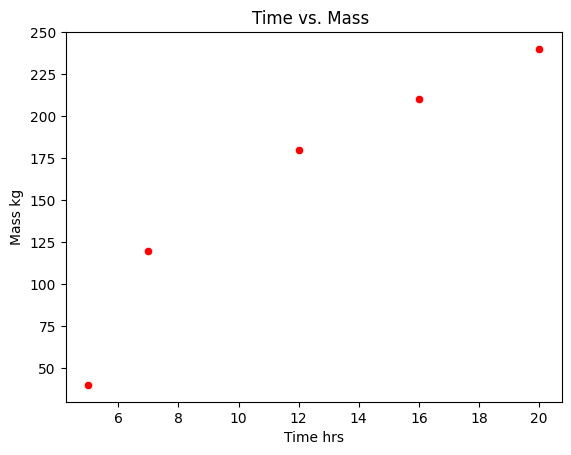

In [ ]:
import seaborn as sns
sns.scatterplot(x='Time', y='Mass', data=clean_data, color='red')
plt.xlabel('Time hrs')
plt.ylabel('Mass kg')
plt.title("Time vs. Mass ")
plt.show()

In [ ]:
X = clean_data['Time'].values
y = clean_data['Mass'].values

In [ ]:
mean_X = np.mean(X)
mean_y = np.mean(y)

In [ ]:
numeinator = np.sum((X - mean_X) * (y - mean_y))
denominator = np.sum((X - mean_X) ** 2)

m = numeinator / denominator
c = mean_y - (m * mean_X)

print(c)
m




11.506493506493513


np.float64(12.207792207792208)

In [ ]:
m = 12.208
c = 11.506

In [ ]:
clean_data['Predicted_Mass'] = m * X + c

In [ ]:
clean_data.head()

,Time,Mass,Predicted_Mass
0,5,40,72.546
1,7,120,96.962
2,12,180,158.002
3,16,210,206.834
4,20,240,255.666


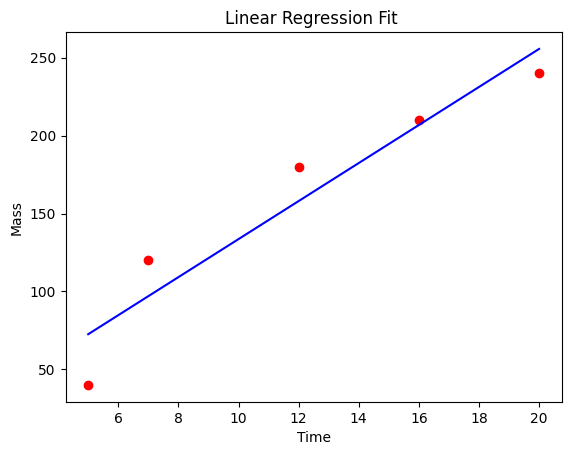

In [ ]:
plt.scatter(clean_data['Time'], clean_data['Mass'], color='red')
plt.plot(clean_data['Time'], clean_data['Predicted_Mass'], color='blue')
plt.xlabel('Time')
plt.ylabel('Mass')
plt.title("Linear Regression Fit ")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmsq = mean_squared_error(y, clean_data['Predicted_Mass'])
r2 = r2_score(y, clean_data['Predicted_Mass'])

print(f"\nMSE: {rmsq:.2f}")
print(f"R² Score: {r2:.2f} (1.0 = Perfect Fit)")


MSE: 465.87
R² Score: 0.91 (1.0 = Perfect Fit)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
dataset = clean_data.copy()

In [ ]:
model = LinearRegression()
X = dataset[['Time']]  # Features (independent variable)
y = dataset['Mass']  # Target (dependent variable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data
model.fit(X_train, y_train)  # Train the model on the training data

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
s = model.predict([[5]])
s

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([57.10794297])

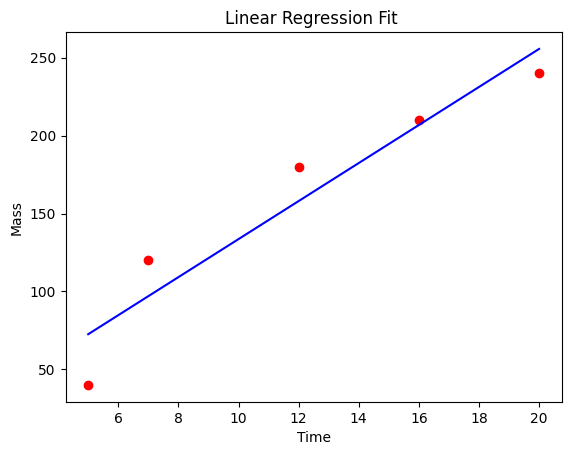

In [ ]:
plt.scatter(dataset['Time'], dataset['Mass'], color='red')
plt.plot(dataset['Time'], dataset['Predicted_Mass'], color='blue')
plt.xlabel('Time')
plt.ylabel('Mass')
plt.title("Linear Regression Fit ")
plt.show()

In [ ]:
rmsq1 = mean_squared_error(y_test, y_pred)
r21 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {rmsq1:.2f}")
print(f"R-squared (R2): {r21:.2f}")


Mean Squared Error (MSE): 1305.40
R-squared (R2): nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
